# Calibration (host noise-floor): CS-01 TAS

**Purpose**: characterise the per-host noise floor that every `experiment` run depends on. Four probes (timer resolution, scheduling jitter, loopback latency, empty-handler scaling) produce one JSON envelope that `05-experimental.ipynb` and `06-yoly-experimental.ipynb` reference when reporting measured latencies.

**Inputs**: none. Host identity (hostname, OS, CPU count, RAM) is snapshotted at runtime.

**Outputs**:
- `data/results/experiment/calibration/<host>_<YYYYMMDD_HHMMSS>.json`: the full calibration envelope.
- `data/img/experiment/calibration/dashboard.{png,svg}`: 2x2 summary card (timer / jitter / loopback / handler scaling).
- `data/img/experiment/calibration/scaling.{png,svg}`: standalone empty-handler scaling line plot.

**Equivalent CLI**:
```bash
python src/methods/calibration.py
```

**How to use the baseline**: every measured experiment latency on this host should be reported as:

```
reported = measured_us - loopback.median_us  +/- jitter.p99_us
```

i.e. subtract the loopback median (host overhead), report the jitter p99 as the uncertainty band. Any measured value below `loopback.median_us` is an instrument error, not a real service. Full plan + checkpoint log in [notes/calibration.md](notes/calibration.md).

This notebook is thin: all logic lives in `src.methods.calibration` (runner) and `src.view.characterization` (plotters). The cells below just call `run()` and display.

In [1]:
%matplotlib inline
from pathlib import Path
import json

import pandas as pd

from src.io import (
    # load_dim_card,
    # load_latest_calibration,
    load_method_cfg,
)
from src.methods.calibration import derive_calib_coefs, run, run_calib_sweep
from src.view import (
    plot_calib_dashboard,
    plot_calib_rate_sweep,
    plot_calib_handler_scaling,
    # plot_yoly_arts_hist,
    # plot_yoly_arts_behaviour,
    # plot_yoly_arts_charts,
    plot_yoly_chart,
)

IMG_ROOT = Path("data/img/experiment/calibration")

# Toggle the rate-saturation probe. Default False so a rerun stays under ~3 min;
# flip to True to also run the experiment-method at the configured rate ladder
# x trials_per_rate (adds ~10-15 min wall time depending on the ladder).
RUN_RATE_SWEEP = True

# Per-request body size (bytes) for the phi coefficient in the dim card.
# Sourced from data/config/method/calibration.json::payload_size_bytes
# (e.g. 131072 = 128 kB). 0 keeps phi NaN (degenerate-memory case).
PAYLOAD_BYTES = int(load_method_cfg("calibration").get("payload_size_bytes", 0))


## 1. Run the four probes

`run()` executes under `winmm.timeBeginPeriod(1)` on Windows (no-op elsewhere). Default sample counts take ~60-90 s on a 16-core laptop; tune via keyword args if needed (e.g. `jitter_samples=500, loopback_samples=500, per_worker=20, n_con_usr=(1, 10)` for a ~8 s smoke).

The envelope is written to `data/results/experiment/calibration/<host>_<timestamp>.json` and returned in-memory for the display cells below.

In [2]:
envelope = run(write=True,
               verbose=True,
               skip_rate_sweep=not RUN_RATE_SWEEP)
print(f"\nwrote: {envelope.get('output_path')}")


  [1/4] timer resolution ...
  [2/4] scheduling jitter ...
  [3/4] loopback latency ...
  [4/4] vernier handler scaling ...
      c=     1  running 200 requests ...
      c=     1  done in 1.0s  median=4724.8us  p99=7396.2us
      c=    10  running 200 requests ...
      c=    10  done in 1.4s  median=34584.4us  p99=775245.9us
      c=    50  running 200 requests ...
      c=    50  done in 1.5s  median=160625.8us  p99=1195810.6us
      c=   100  running 200 requests ...
      c=   100  done in 1.6s  median=458515.8us  p99=1485495.0us
      c=   200  running 200 requests ...
      c=   200  done in 1.6s  median=808181.6us  p99=1412325.3us
      c=   300  running 300 requests ...
      c=   300  done in 2.3s  median=975428.6us  p99=2165878.1us
      c=   500  running 500 requests ...
      c=   500  done in 5.3s  median=1451796.9us  p99=5102671.5us
      c=   700  running 700 requests ...
      c=   700  done in 5.7s  median=1801141.2us  p99=5579435.0us
      c=  1000  running 1000 requ

## 2. Host profile

The machine the rest of the calibration was measured against. Record thermals / background load conditions in [notes/devlog.md](notes/devlog.md) when benching formally.

In [3]:
host = envelope["host_profile"]
pd.Series({
    "hostname": host.get("hostname"),
    "os": host.get("os"),
    "python": f"{host.get('python')} ({host.get('python_impl')})",
    "cpu_count": host.get("cpu_count"),
    "cpu_machine": host.get("cpu_machine"),
    "ram_total_gb": round(float(host.get("ram_total_gb") or 0), 2),
    "timestamp": envelope.get("timestamp"),
    "elapsed_s": envelope.get("elapsed_s"),
}, name="value")

hostname                  DESKTOP-INKGBK6
os              Windows-11-10.0.26200-SP0
python                  3.12.10 (CPython)
cpu_count                              16
cpu_machine                         AMD64
ram_total_gb                        63.75
timestamp             2026-05-03T03:06:53
elapsed_s                         452.507
Name: value, dtype: object

## 3. Probe summary tables

Each probe reports a distribution summary. Acronyms expanded below:

- **min**: minimum observed value; for `timer` this is the actual clock resolution.
- **median / p50**: 50th percentile (half the samples are faster, half slower).
- **mean**: arithmetic mean.
- **p95 / p99**: 95th / 99th percentile (worst-case tail behaviour).
- **max**: single worst sample.
- **std**: standard deviation (dispersion).
- **ns**: nanoseconds (10^-9 s).  **us**: microseconds (10^-6 s).

In [4]:
timer = envelope.get("timer", {})
jitter = envelope.get("jitter", {})
loopback = envelope.get("loopback", {})

pd.DataFrame({
    r"timer [$\mathbf{ns}$]": {
        "min": timer.get("min_ns"),
        "median / p50": timer.get("median_ns"),
        "mean": timer.get("mean_ns"),
        "std": timer.get("std_ns"),
    },
    r"jitter [$\mathbf{\mu s}$]": {
        "mean": jitter.get("mean_us"),
        "median / p50": jitter.get("p50_us"),
        "p99": jitter.get("p99_us"),
        "max": jitter.get("max_us"),
    },
    r"loopback [$\mathbf{\mu s}$]": {
        "min": loopback.get("min_us"),
        "median / p50": loopback.get("median_us"),
        "p95": loopback.get("p95_us"),
        "p99": loopback.get("p99_us"),
    },
}).round(2)

,timer [$\mathbf{ns}$],jitter [$\mathbf{\mu s}$],loopback [$\mathbf{\mu s}$]
min,100.00,NaN,3160.60
median / p50,200.00,557.30,4457.20
mean,208.32,757.80,NaN
std,469.85,NaN,NaN
p99,NaN,3768.77,9115.16
max,NaN,51349.70,NaN
p95,NaN,NaN,6894.70


## 4. Handler scaling table

Empty `/ping` endpoint, keep-alive, measured at increasing in-flight request counts. Growing gap between `c=1` and `c=10` indicates how much the FastAPI event loop queues when concurrent requests stack up; often the real driver of prototype latency rise at high rates.

In [5]:
handler = envelope.get("handler_scaling", {})
rows = []
for c, stats in sorted(handler.items(), key=lambda p: int(p[0])):
    rows.append({
        r"$\mathbf{n_{con\,usr}}$": int(c),
        r"min [$\mathbf{\mu s}$]": stats.get("min_us"),
        r"median / p50 [$\mathbf{\mu s}$]": stats.get("median_us"),
        r"p95 [$\mathbf{\mu s}$]": stats.get("p95_us"),
        r"p99 [$\mathbf{\mu s}$]": stats.get("p99_us"),
        "samples": stats.get("samples"),
    })
pd.DataFrame(rows).set_index(r"$\mathbf{n_{con\,usr}}$").round(1)

,min [$\mathbf{\mu s}$],median / p50 [$\mathbf{\mu s}$],p95 [$\mathbf{\mu s}$],p99 [$\mathbf{\mu s}$],samples
"$\mathbf{n_{con\,usr}}$",,,,,
1,3470.5,4724.8,6721.4,7396.2,200
10,5405.6,34584.4,80150.8,775245.9,200
50,9912.3,160625.8,795216.5,1195810.6,200
100,20713.8,458515.8,1317894.6,1485495.0,200
200,396185.4,808181.6,1332099.1,1412325.3,200
300,516642.2,975428.6,2007048.7,2165878.1,200
500,1197983.5,1451796.9,4817605.9,5102671.5,200
700,1398867.3,1801141.2,5188284.4,5579435.0,200
1000,2311764.7,2989517.6,8293160.8,8603288.3,200


## 5. Calibration dashboard (single-figure summary)

2x2 card combining the three headline bar charts with the handler-scaling line plot. The suptitle carries the host identity, timestamp, and the `reported = measured - loopback_median +/- jitter_p99` formula so the figure is usable on its own as a dissertation appendix.

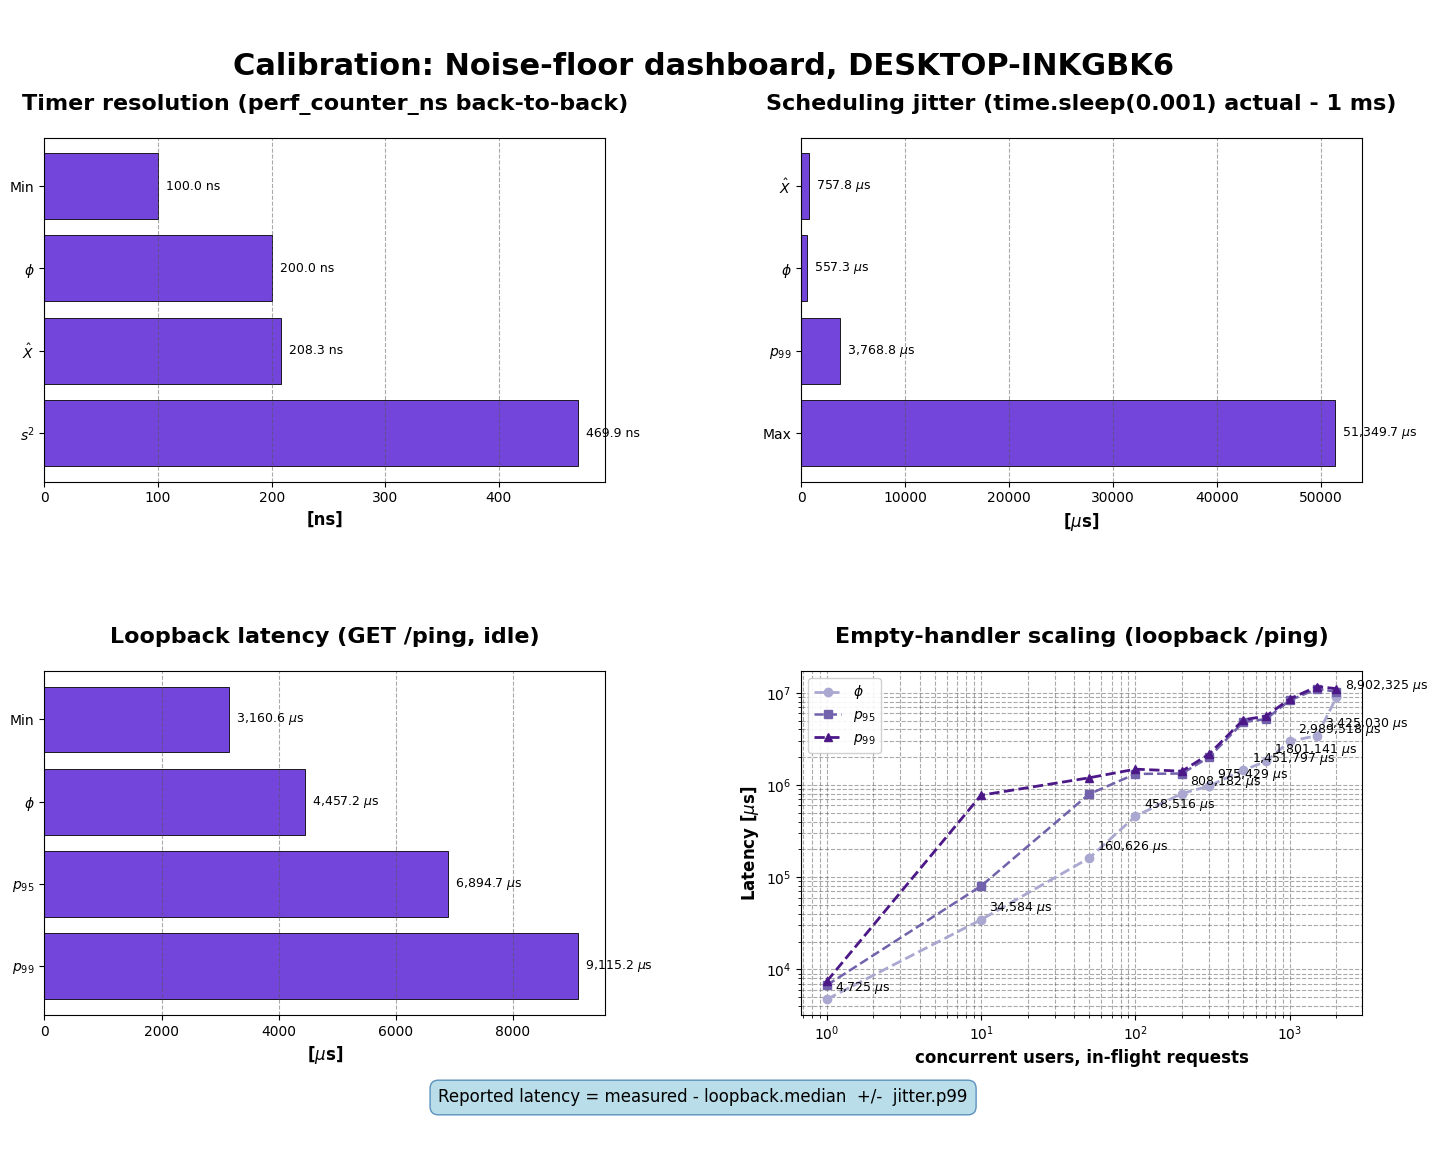

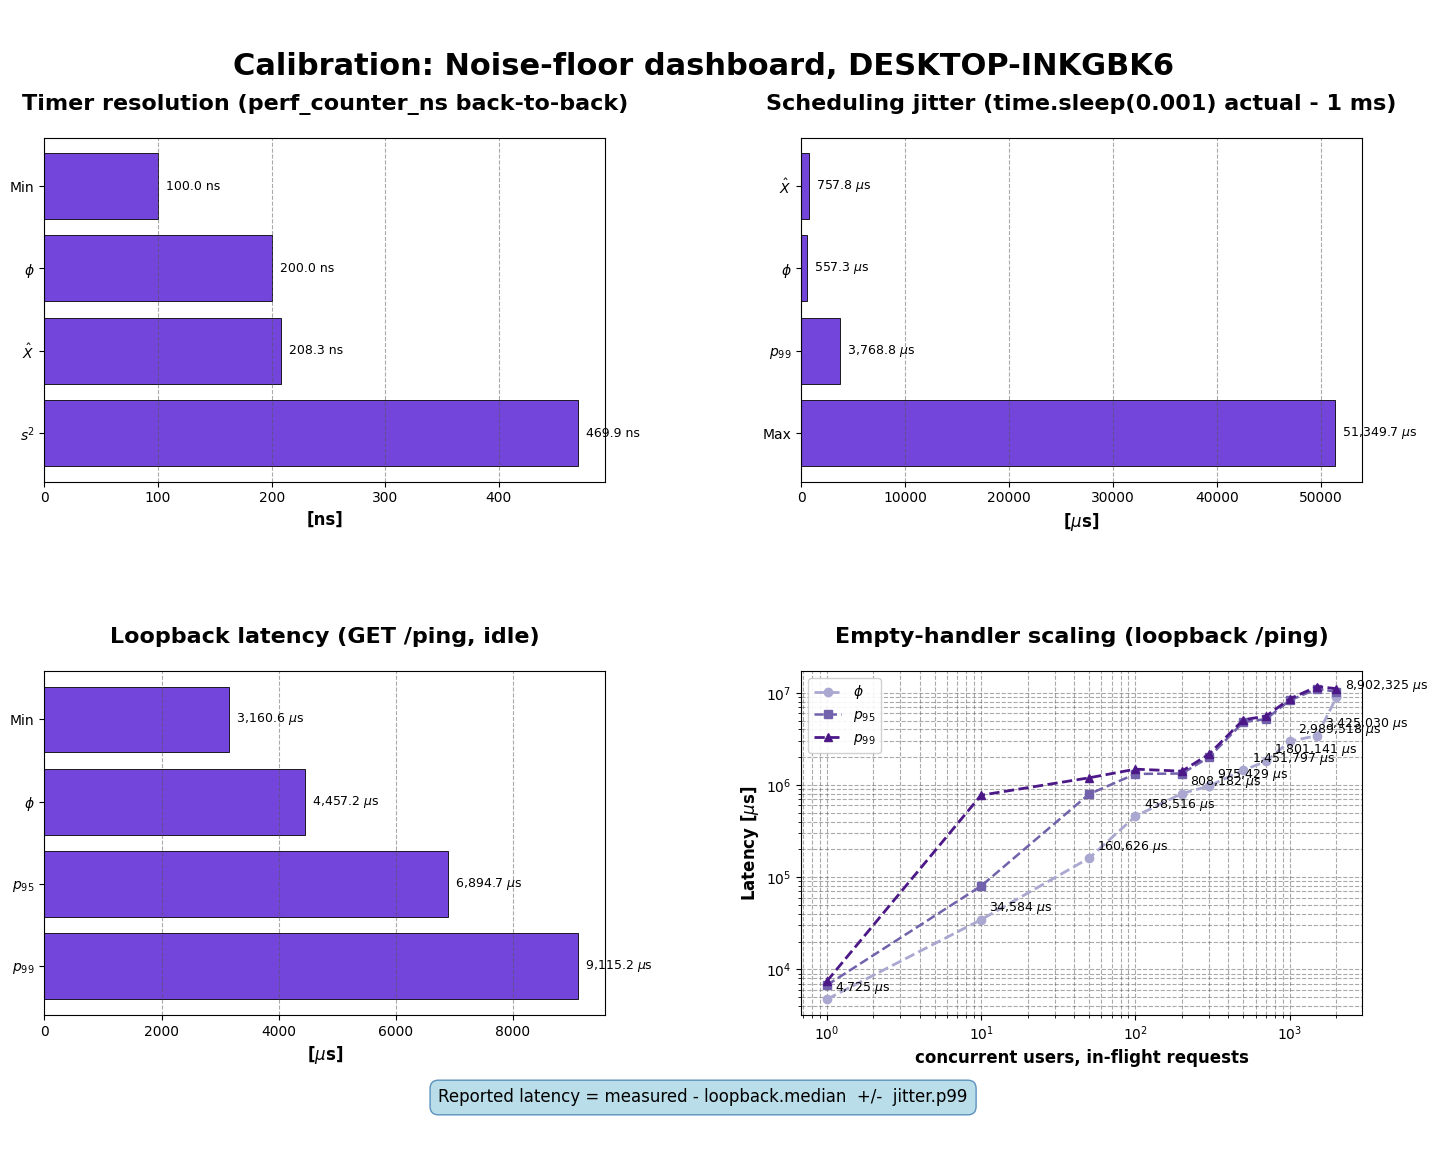

In [6]:
plot_calib_dashboard(
    envelope,
    title=f"Calibration: Noise-floor dashboard, {host.get('hostname')}",
    file_path=str(IMG_ROOT),
    fname="dashboard.png",
)

## 6. Handler-scaling detail

Standalone line plot: median (p50), 95th percentile (p95), 99th percentile (p99) vs `n_con_usr` (concurrent users, in-flight requests) on the CLIENT side. The SERVICE stays at `c_srv=1` (single uvicorn worker) throughout. Log-log axes so the span from `n_con_usr=1` to `n_con_usr=10000` is legible.

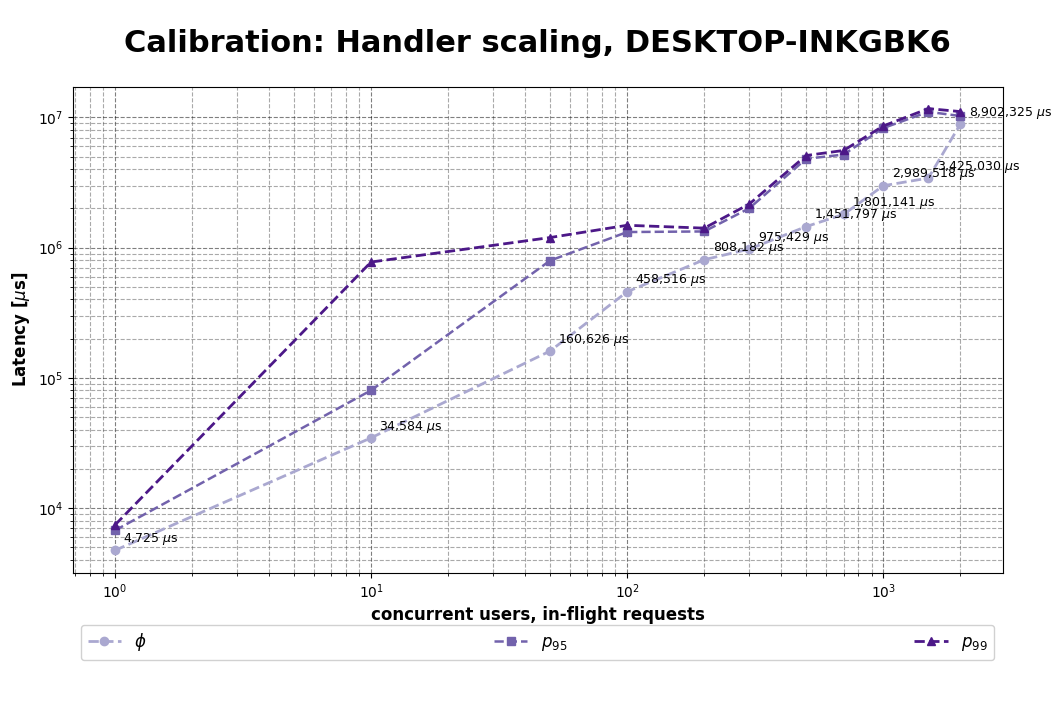

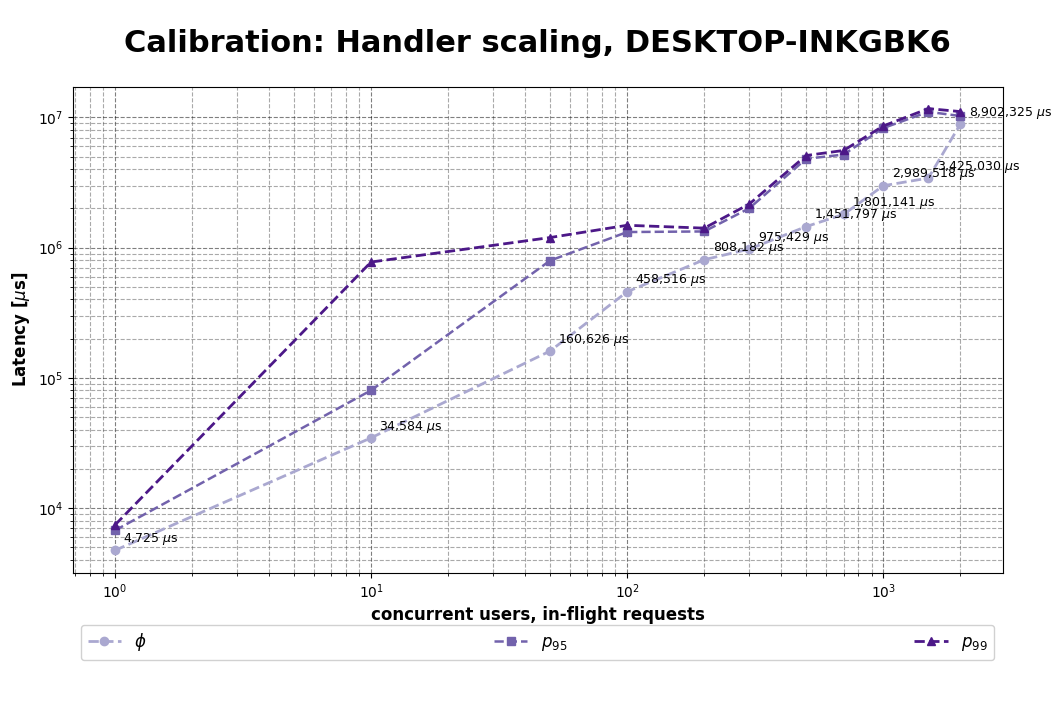

In [7]:
plot_calib_handler_scaling(
    envelope.get("handler_scaling", {}),
    title=f"Calibration: Handler scaling, {host.get('hostname')}",
    file_path=str(IMG_ROOT),
    fname="scaling.png",
)

## 6b. Single-worker push-back card (closed-loop)

**Question this answers**: *where does a **single worker (c=1)** collapse under increasing concurrent load?*

Closed-loop / push-back probe. Re-uses the `handler_scaling` data already collected by `run()` in section 4 (no new measurements; no extra wall time). At each `n_con_usr` level the client holds N requests in flight against a fixed `c_srv=1` vernier; the dimensional coefficients capture the host's response. K is tiled across `sweep_grid.K = [32, 256, 512]` so the chart paints one trajectory per K-band along the `c=1` slice.

This is the **`c=1` boundary slice** of the richer `(c, K, mu)` cloud rendered in section 7b. Section 7b drives multi-worker (`c=8..128`) targets at deterministic rates and is the more informative view; this section is the cheap single-worker baseline derived from data we already have.

Coefficients (derived from measurement, not from an M/M/c/K prediction):

- **$\theta = L / K$**: queue occupancy.
- **$\sigma = W \lambda / K$**: stall; queueing share of capacity.
- **$\eta = X K / (\mu c_{srv})$**: effective-yield vs host service-rate ceiling.
- **$\phi = (L \cdot \mathrm{payload}) / (K \cdot \mathrm{payload}) = L / K$**: memory-usage; degenerate here because every `/ping` request carries the same payload (so $\phi \equiv \theta$). Populated with `NaN` when `payload_size_bytes=0`; informative only with the payload-echo upgrade.
- **$\varepsilon$** is structurally 0 (the service has no business logic that can fail) and is therefore NOT part of this card.

`mu_req_per_s = 1e6 / loopback.median_us` (the host's idle service-rate ceiling). The 2x2 figure reuses `src.view.plot_yoly_chart`. Saved as `dim_card.{png,svg}`.

pipeline       : pydasa.MonteCarloSimulation(mode=DATA)
payload_size_B : 128000
mu_req_per_s   : 224.36
K_values       : [128, 256, 512, 1024]
n_con_usr      : [1, 10, 50, 100, 200, 300, 500, 700, 1000, 1500, 2000, 1, 10, 50, 100, 200, 300, 500, 700, 1000, 1500, 2000, 1, 10, 50, 100, 200, 300, 500, 700, 1000, 1500, 2000, 1, 10, 50, 100, 200, 300, 500, 700, 1000, 1500, 2000]


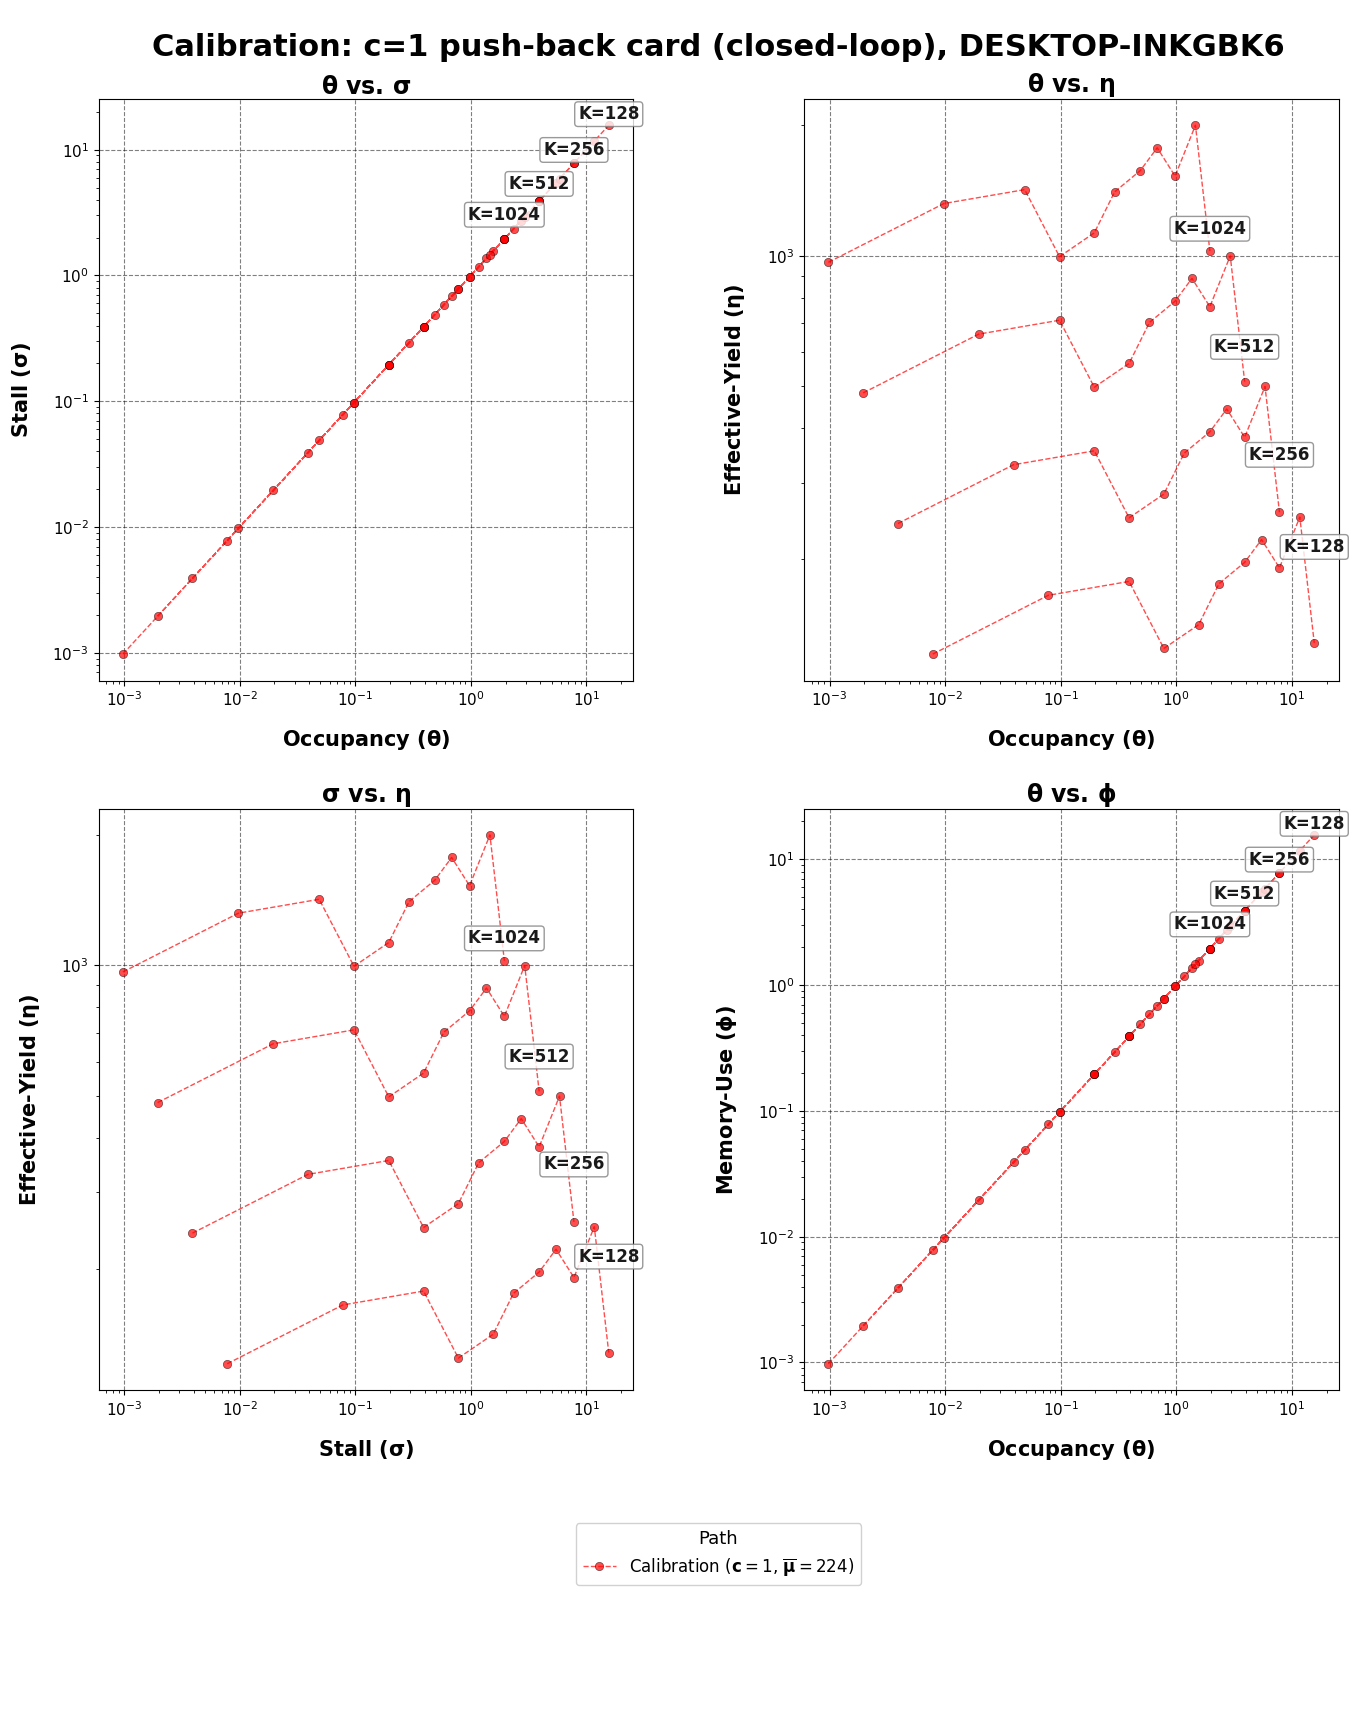

In [8]:
# closed-loop / push-back card: c=1, varying n_con_usr, K tiled across sweep_grid.K. Reuses the handler_scaling block already collected in section 4 (no new measurements). This is the c=1 boundary slice of the richer multi-worker cloud rendered in section 7b -- pairs with that section to answer "where does a single worker collapse under increasing concurrent load?"
_sweep_grid = load_method_cfg("calibration").get("sweep_grid", {})
_K_VALUES = [int(_k) for _k in _sweep_grid.get("K", [])]

dim_card = derive_calib_coefs(envelope,
                              payload_size_bytes=PAYLOAD_BYTES,
                              K_values=_K_VALUES if _K_VALUES else None)

if not dim_card:
    print("dimensional_card unavailable -- loopback or handler_scaling missing.")
else:
    meta = dim_card.get("meta", {})
    print(f"pipeline       : {meta.get('pipeline')}")
    print(f"payload_size_B : {meta.get('payload_size_bytes')}")
    print(f"mu_req_per_s   : {meta.get('mu_req_per_s'):.2f}")
    print(f"K_values       : {meta.get('K_values')}")
    print(f"n_con_usr      : {meta.get('n_con_usr')}")

    logscale = bool(PAYLOAD_BYTES)  # phi is NaN when payload=0 -> linear scale
    plot_yoly_chart(
        dim_card,
        paths={"Calibration": "CALIB"},
        logscale=logscale,
        title=f"Calibration: c=1 push-back card (closed-loop), {host.get('hostname')}",
        file_path=str(IMG_ROOT),
        fname="dim_card.png",
        verbose=False,
    )


## 7. Rate saturation (optional)

Only populated when `RUN_RATE_SWEEP = True` in the setup cell. Drives the standalone vernier ping/echo service at the configured rate ladder (default `[10, 50, 100, 200, 250, 300, 400, 500]` req/s x 11 trials) and reports the highest rate the host sustains under the configured loss target. Pure host-transport saturation, decoupled from the TAS profile (full-mesh saturation testing belongs in the experiment notebook itself).

Figure saved as `rate_sweep.{png,svg}` alongside the dashboard.

,effective mean,effective range,mean loss [%],trials
target [req/s],,,,
10.0,10.857,"[10.67, 11.33]",-8.571,7
50.0,50.952,"[50.67, 51.33]",-1.905,7
200.0,199.810,"[198.67, 200.67]",0.095,7
300.0,284.381,"[252.67, 296.67]",5.206,7
400.0,359.143,"[308.67, 398.00]",10.214,7
500.0,402.762,"[352.00, 487.33]",19.448,7
510.0,442.952,"[377.33, 495.33]",13.147,7



Highest sustainable rate at <= 2.5% mean loss: 200.0 req/s


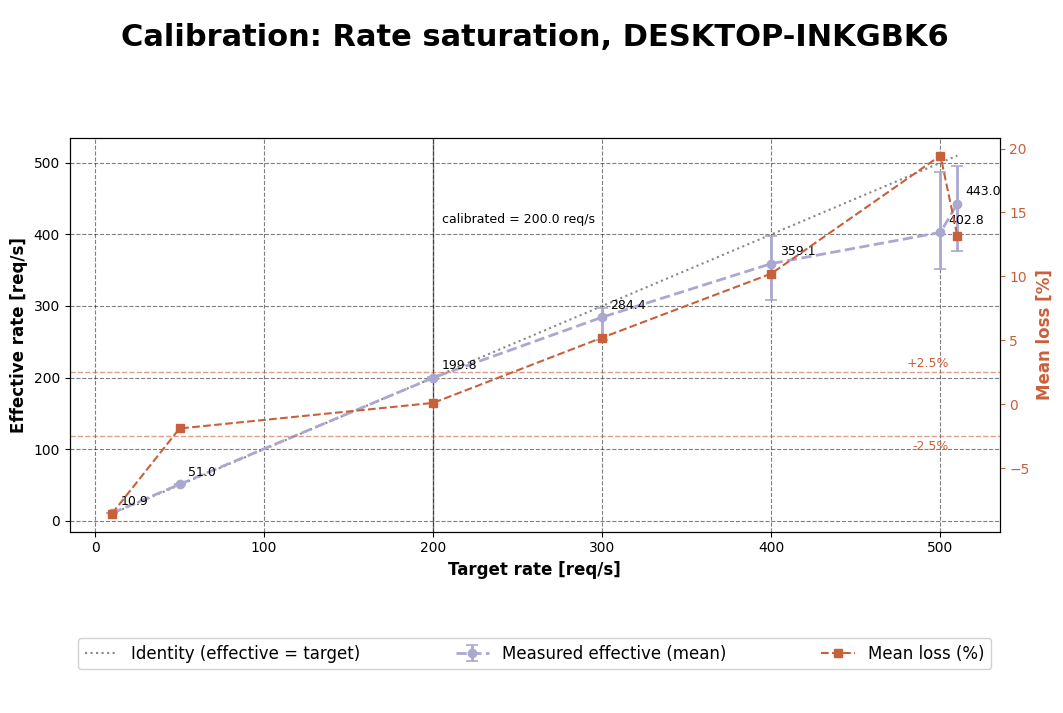

In [9]:
rate_sweep = envelope.get("rate_sweep")
if rate_sweep is None:
    print("rate_sweep block absent -- set RUN_RATE_SWEEP = True and re-run "
          "the probe cell to populate it.")
else:
    rows = []
    for k in sorted(rate_sweep["aggregates"].keys(), key=lambda x: float(x)):
        a = rate_sweep["aggregates"][k]
        rows.append({
            "target [req/s]": float(k),
            "effective mean": a.get("mean"),
            "effective range": f'[{a.get("lo", 0):.2f}, {a.get("hi", 0):.2f}]',
            "mean loss [%]": a.get("mean_loss_pct"),
            "trials": a.get("n"),
        })
    display(pd.DataFrame(rows).set_index("target [req/s]").round(3))
    cal = rate_sweep.get("calibrated_rate")
    target = rate_sweep.get("target_loss_pct")
    if cal is None:
        print(f"\nNo rate cleared the {target}% mean-loss bar.")
    else:
        print(f"\nHighest sustainable rate at <= {target}% mean loss: "
              f"{float(cal):.1f} req/s")

    plot_calib_rate_sweep(
        rate_sweep,
        title=f"Calibration: Rate saturation, {host.get('hostname')}",
        file_path=str(IMG_ROOT),
        fname="rate_sweep.png",
    )


## 7b. Multi-worker rate-driven sweep (open-loop)

**Question this answers**: *where do **multiple workers (c=8..128)** collapse under increasing arrival rate?*

Open-loop / rate-driven probe. Drives the vernier echo service across the `sweep_grid` cartesian (`mu_factor x c x K`) using `run_calib_sweep`. Each combo spins up a fresh vernier with the combo's spec, ramps `lambda` from `lambda_factor_min*mu` up to `util_threshold*mu*c` across `lambda_steps` deterministic target rates, and feeds the per-step latency stats through `derive_calib_coefs` to produce one dim card per combo. No queue theory, just real measurements.

**Complementary to section 6b**: 6b answers the closed-loop / push-back question (single worker under increasing concurrent load); this section answers the open-loop / rate-driven question (multiple workers under increasing arrival rate). 6b's c=1 slice is the boundary of the cloud this section paints.

**Off by default.** Set `RUN_CALIB_SWEEP = True` below to opt in. Default grid (`mu_factor=[0.5,1,1.5,2]` x `c=[8,32,64,128]` x `K=[32,256,512]`) yields 48 combos; total wall time scales with `lambda_steps * max_probe_window_s` per combo plus `inter_trial_delay_s` between combos.

Anchor for `mu_combo = mu_factor * mu_anchor` resolves through `sweep_grid.mu_anchor_req_per_s` (explicit, host-independent) -> `sweep_grid.mu_anchor_source` (named derivation, defaults to `loopback.median_us`). Provenance lands on every per-combo `meta` block.

In [ ]:
# RUN_CALIB_SWEEP=False reuses the most recent <host>_<ts>_sweep.json on disk
# via the fallback loader cell below; flip to True only when you intend to
# rerun the multi-minute (c x K x mu_factor) cartesian (~25 min on this host
# at sweep_grid.c=[8,32,64,128]). At high c values, TCP TIME_WAIT on port 8765
# causes back-pressure that stalls the sweep -- shrink c / bump
# inter_trial_delay_s before re-enabling.
RUN_CALIB_SWEEP = True

if RUN_CALIB_SWEEP:
    sweep = run_calib_sweep(envelope, write=True, verbose=True)
    print()
    print(f"combos: {len(sweep)}")
    if not sweep:
        print("sweep returned empty -- check loopback or sweep_grid in calibration.json")
else:
    sweep = {}
    print("sweep skipped (set RUN_CALIB_SWEEP = True to opt in; "
          "~25 min for the default 48-combo grid)")

  [1/64] CALIBc16K128m50 mu=62.5 req/s ...
  [2/64] CALIBc16K128m100 mu=125.0 req/s ...
  [3/64] CALIBc16K128m150 mu=187.5 req/s ...
  [4/64] CALIBc16K128m200 mu=250.0 req/s ...
  [5/64] CALIBc16K256m50 mu=62.5 req/s ...
  [6/64] CALIBc16K256m100 mu=125.0 req/s ...
  [7/64] CALIBc16K256m150 mu=187.5 req/s ...
  [8/64] CALIBc16K256m200 mu=250.0 req/s ...
  [9/64] CALIBc16K512m50 mu=62.5 req/s ...
  [10/64] CALIBc16K512m100 mu=125.0 req/s ...
  [11/64] CALIBc16K512m150 mu=187.5 req/s ...
  [12/64] CALIBc16K512m200 mu=250.0 req/s ...
  [13/64] CALIBc16K1024m50 mu=62.5 req/s ...


In [ ]:
# fallback loader: when `RUN_CALIB_SWEEP=False` AND `sweep` has no data
# in memory (fresh kernel or skipped cell 19), load the most recent
# <host>_<ts>_sweep.json from disk so the plot cell below can render
# without re-running the multi-minute sweep.
sweep = globals().get("sweep") or {}

if not sweep:
    sweep_dir = Path("data/results/experiment/calibration")
    host_stem = (envelope.get("host_profile", {})
                          .get("hostname", "")
                          .replace(" ", "-"))
    candidates = sorted(sweep_dir.glob(f"{host_stem}_*_sweep.json"))
    if candidates:
        latest = candidates[-1]
        sweep = json.loads(latest.read_text(encoding="utf-8"))["combos"]
        print(f"loaded {len(sweep)} combos from {latest.name}")
    else:
        print(f"no sweep file matching {host_stem}_*_sweep.json under {sweep_dir}")
else:
    print(f"sweep already populated ({len(sweep)} combos); skipping disk load")


In [ ]:
# open-loop / rate-driven sweep cloud: each (c, K, mu_factor) combo is driven at deterministic target rates and contributes one trajectory. Pairs with section 6b (the c=1 closed-loop boundary) -- this section answers "where do multiple workers collapse under increasing arrival rate?" Rerun this cell after tweaking the plot config without re-running the multi-minute sweep above.
if sweep:
    # flatten nested {combo_tag: {symbol: array}} into one coeff_data dict
    overlay = {}
    for tag, block in sweep.items():
        for key, val in block.items():
            if key == "meta":
                continue
            overlay[key] = val
    # plot_yoly_chart wants {display_label: combo_tag}. The label MUST include mu (not just c, K) or combos with the same (c, K) but different mu_factor dedupe in the dict and only one per (c, K) survives. Each combo's actual mu is meta.mu_req_per_s = mu_factor * mu_anchor; we render it as a bold-math mu in the legend so the format pairs with the architecture yoly chart.
    scenarios = {}
    for tag, block in sweep.items():
        meta = block.get("meta", {})
        _c_val = meta.get("c_srv")
        _K_val = meta.get("K_capacity")
        _mu_val = round(float(meta.get("mu_req_per_s", 0.0)))
        label = (rf"$\mathbf{{c}}={_c_val},\,\mathbf{{K}}={_K_val},\,"
                 rf"\mathbf{{\mu}}={_mu_val}$")
        scenarios[label] = tag
    plot_yoly_chart(overlay,
                    scenarios=scenarios,
                    title=f"Calibration: Multi-worker rate-driven sweep, {host.get('hostname')}",
                    file_path=str(IMG_ROOT),
                    fname="calib_sweep",
                    verbose=True)
else:
    print("no sweep in memory -- run the cell above with RUN_CALIB_SWEEP = True")

## 8. Apply the baseline to experiment results

The two numbers that matter when reporting later experiments on this host:


In [ ]:
floor = float(loopback.get("median_us", 0.0))
band = float(jitter.get("p99_us", 0.0))
print(f"Loopback median (host overhead) : {floor:,.1f} us")
print(f"Jitter p99 (uncertainty band)   : {band:,.1f} us")
print()

print("Example: a measured experiment latency of 8300 us reports as:")
print(f"  {8300 - floor:,.1f} us  +/- {band:,.1f} us")
print()

print("Any measured latency below the host overhead is an instrument error.")

## Summary

Run this notebook before every fresh `05-experimental.ipynb` / `06-yoly-experimental.ipynb` session so the downstream cells can load the latest calibration JSON by timestamp. A stale baseline is fine for iteration; a dissertation-quality run pairs every experiment result with a same-session calibration.

**Next in the pipeline**: `05-experimental.ipynb` (fixed-point per-adaptation execution) and `06-yoly-experimental.ipynb` (configuration-sweep yoly).